In [1]:
from kan import *

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = KAN(width=[2,5,1], grid=5, k=3, seed=0,device=device)

checkpoint directory created: ./model
saving model version 0.0


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Load your dataset
# data = pd.read_csv('clean_male.csv', usecols=[2,3,4,10,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,29,31,32,33,34])
data = pd.read_csv('clean_male.csv', usecols=[2,3,4,10,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,29,31,32,33,34])

In [3]:
import matplotlib
matplotlib.rc("font",family='YouYuan')

In [4]:
num = len(data)
print(num)

1082


C:\Users\qqq\AppData\Local\Temp\ipykernel_31884\2647964432.py:21: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from current font.
  plt.tight_layout()
C:\Users\qqq\AppData\Local\Temp\ipykernel_31884\2647964432.py:21: UserWarning: Glyph 40836 (\N{CJK UNIFIED IDEOGRAPH-9F84}) missing from current font.
  plt.tight_layout()
C:\Users\qqq\AppData\Local\Temp\ipykernel_31884\2647964432.py:21: UserWarning: Glyph 36523 (\N{CJK UNIFIED IDEOGRAPH-8EAB}) missing from current font.
  plt.tight_layout()
C:\Users\qqq\AppData\Local\Temp\ipykernel_31884\2647964432.py:21: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from current font.
  plt.tight_layout()
C:\Users\qqq\AppData\Local\Temp\ipykernel_31884\2647964432.py:21: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from current font.
  plt.tight_layout()
C:\Users\qqq\AppData\Local\Temp\ipykernel_31884\2647964432.py:21: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from cur

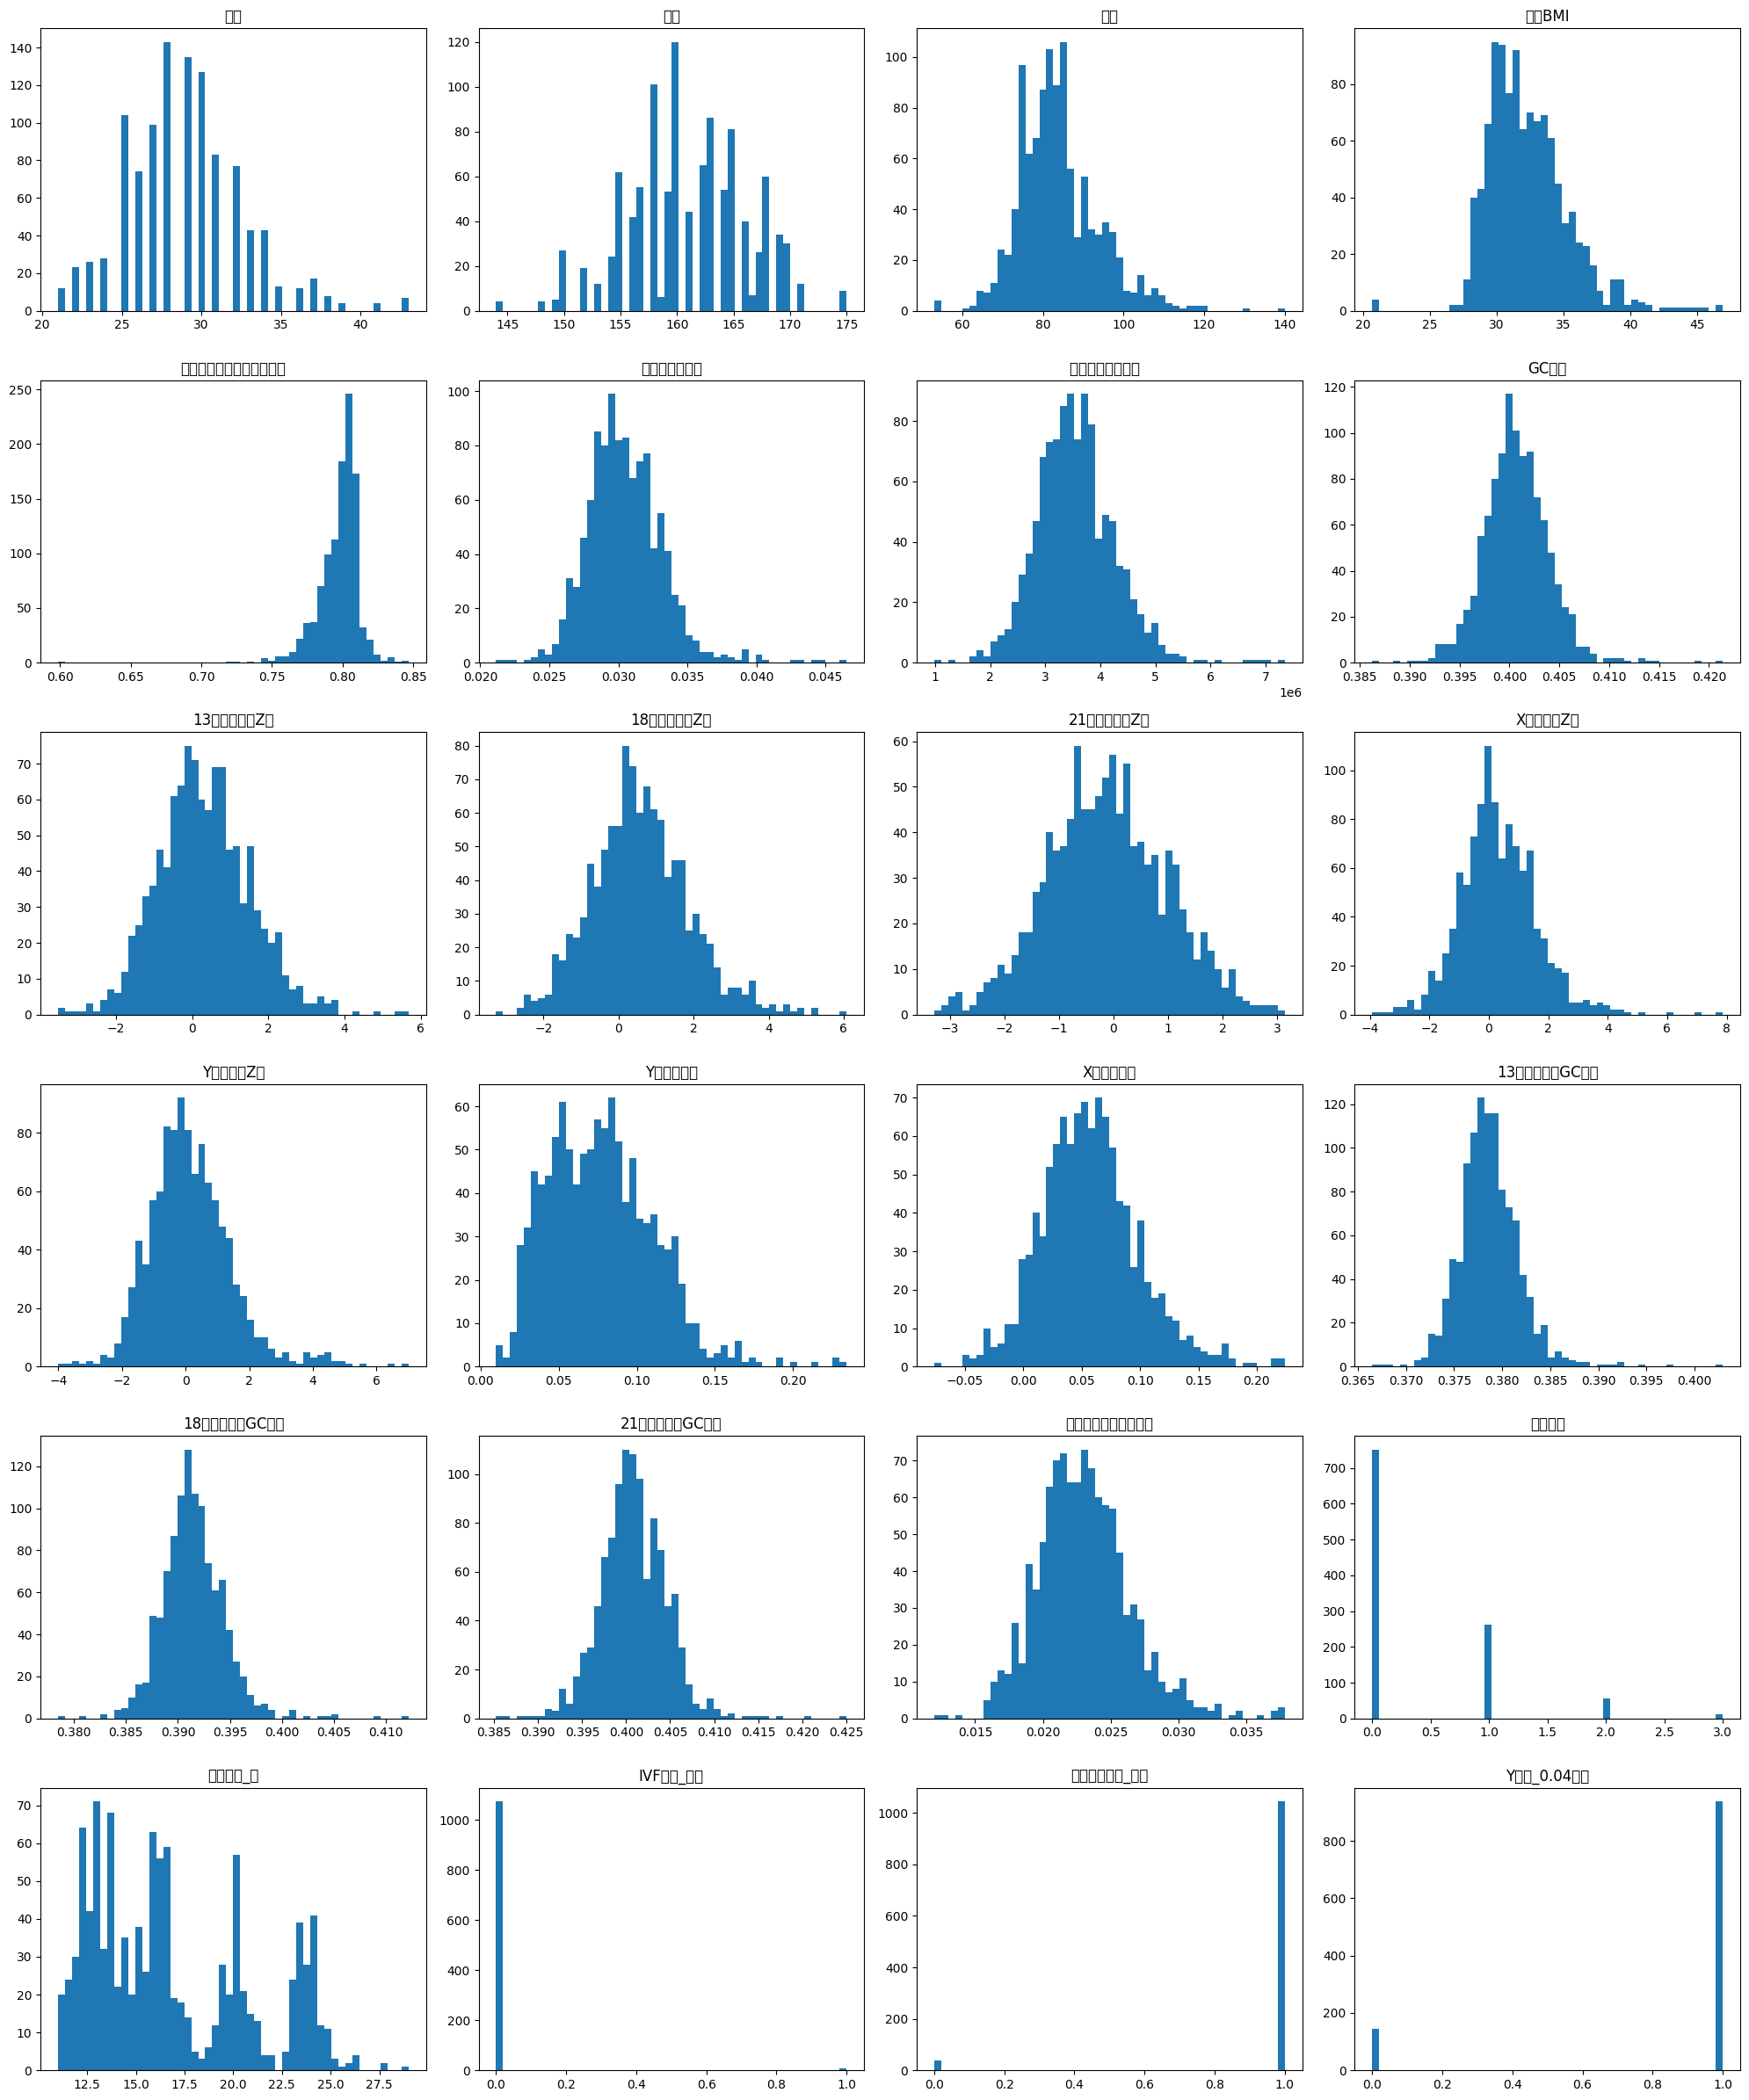

C:\Users\qqq\AppData\Local\Temp\ipykernel_31884\2647964432.py:37: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from current font.
  plt.tight_layout()
C:\Users\qqq\AppData\Local\Temp\ipykernel_31884\2647964432.py:37: UserWarning: Glyph 40836 (\N{CJK UNIFIED IDEOGRAPH-9F84}) missing from current font.
  plt.tight_layout()
C:\Users\qqq\AppData\Local\Temp\ipykernel_31884\2647964432.py:37: UserWarning: Glyph 36523 (\N{CJK UNIFIED IDEOGRAPH-8EAB}) missing from current font.
  plt.tight_layout()
C:\Users\qqq\AppData\Local\Temp\ipykernel_31884\2647964432.py:37: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from current font.
  plt.tight_layout()
C:\Users\qqq\AppData\Local\Temp\ipykernel_31884\2647964432.py:37: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from current font.
  plt.tight_layout()
C:\Users\qqq\AppData\Local\Temp\ipykernel_31884\2647964432.py:37: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from cur

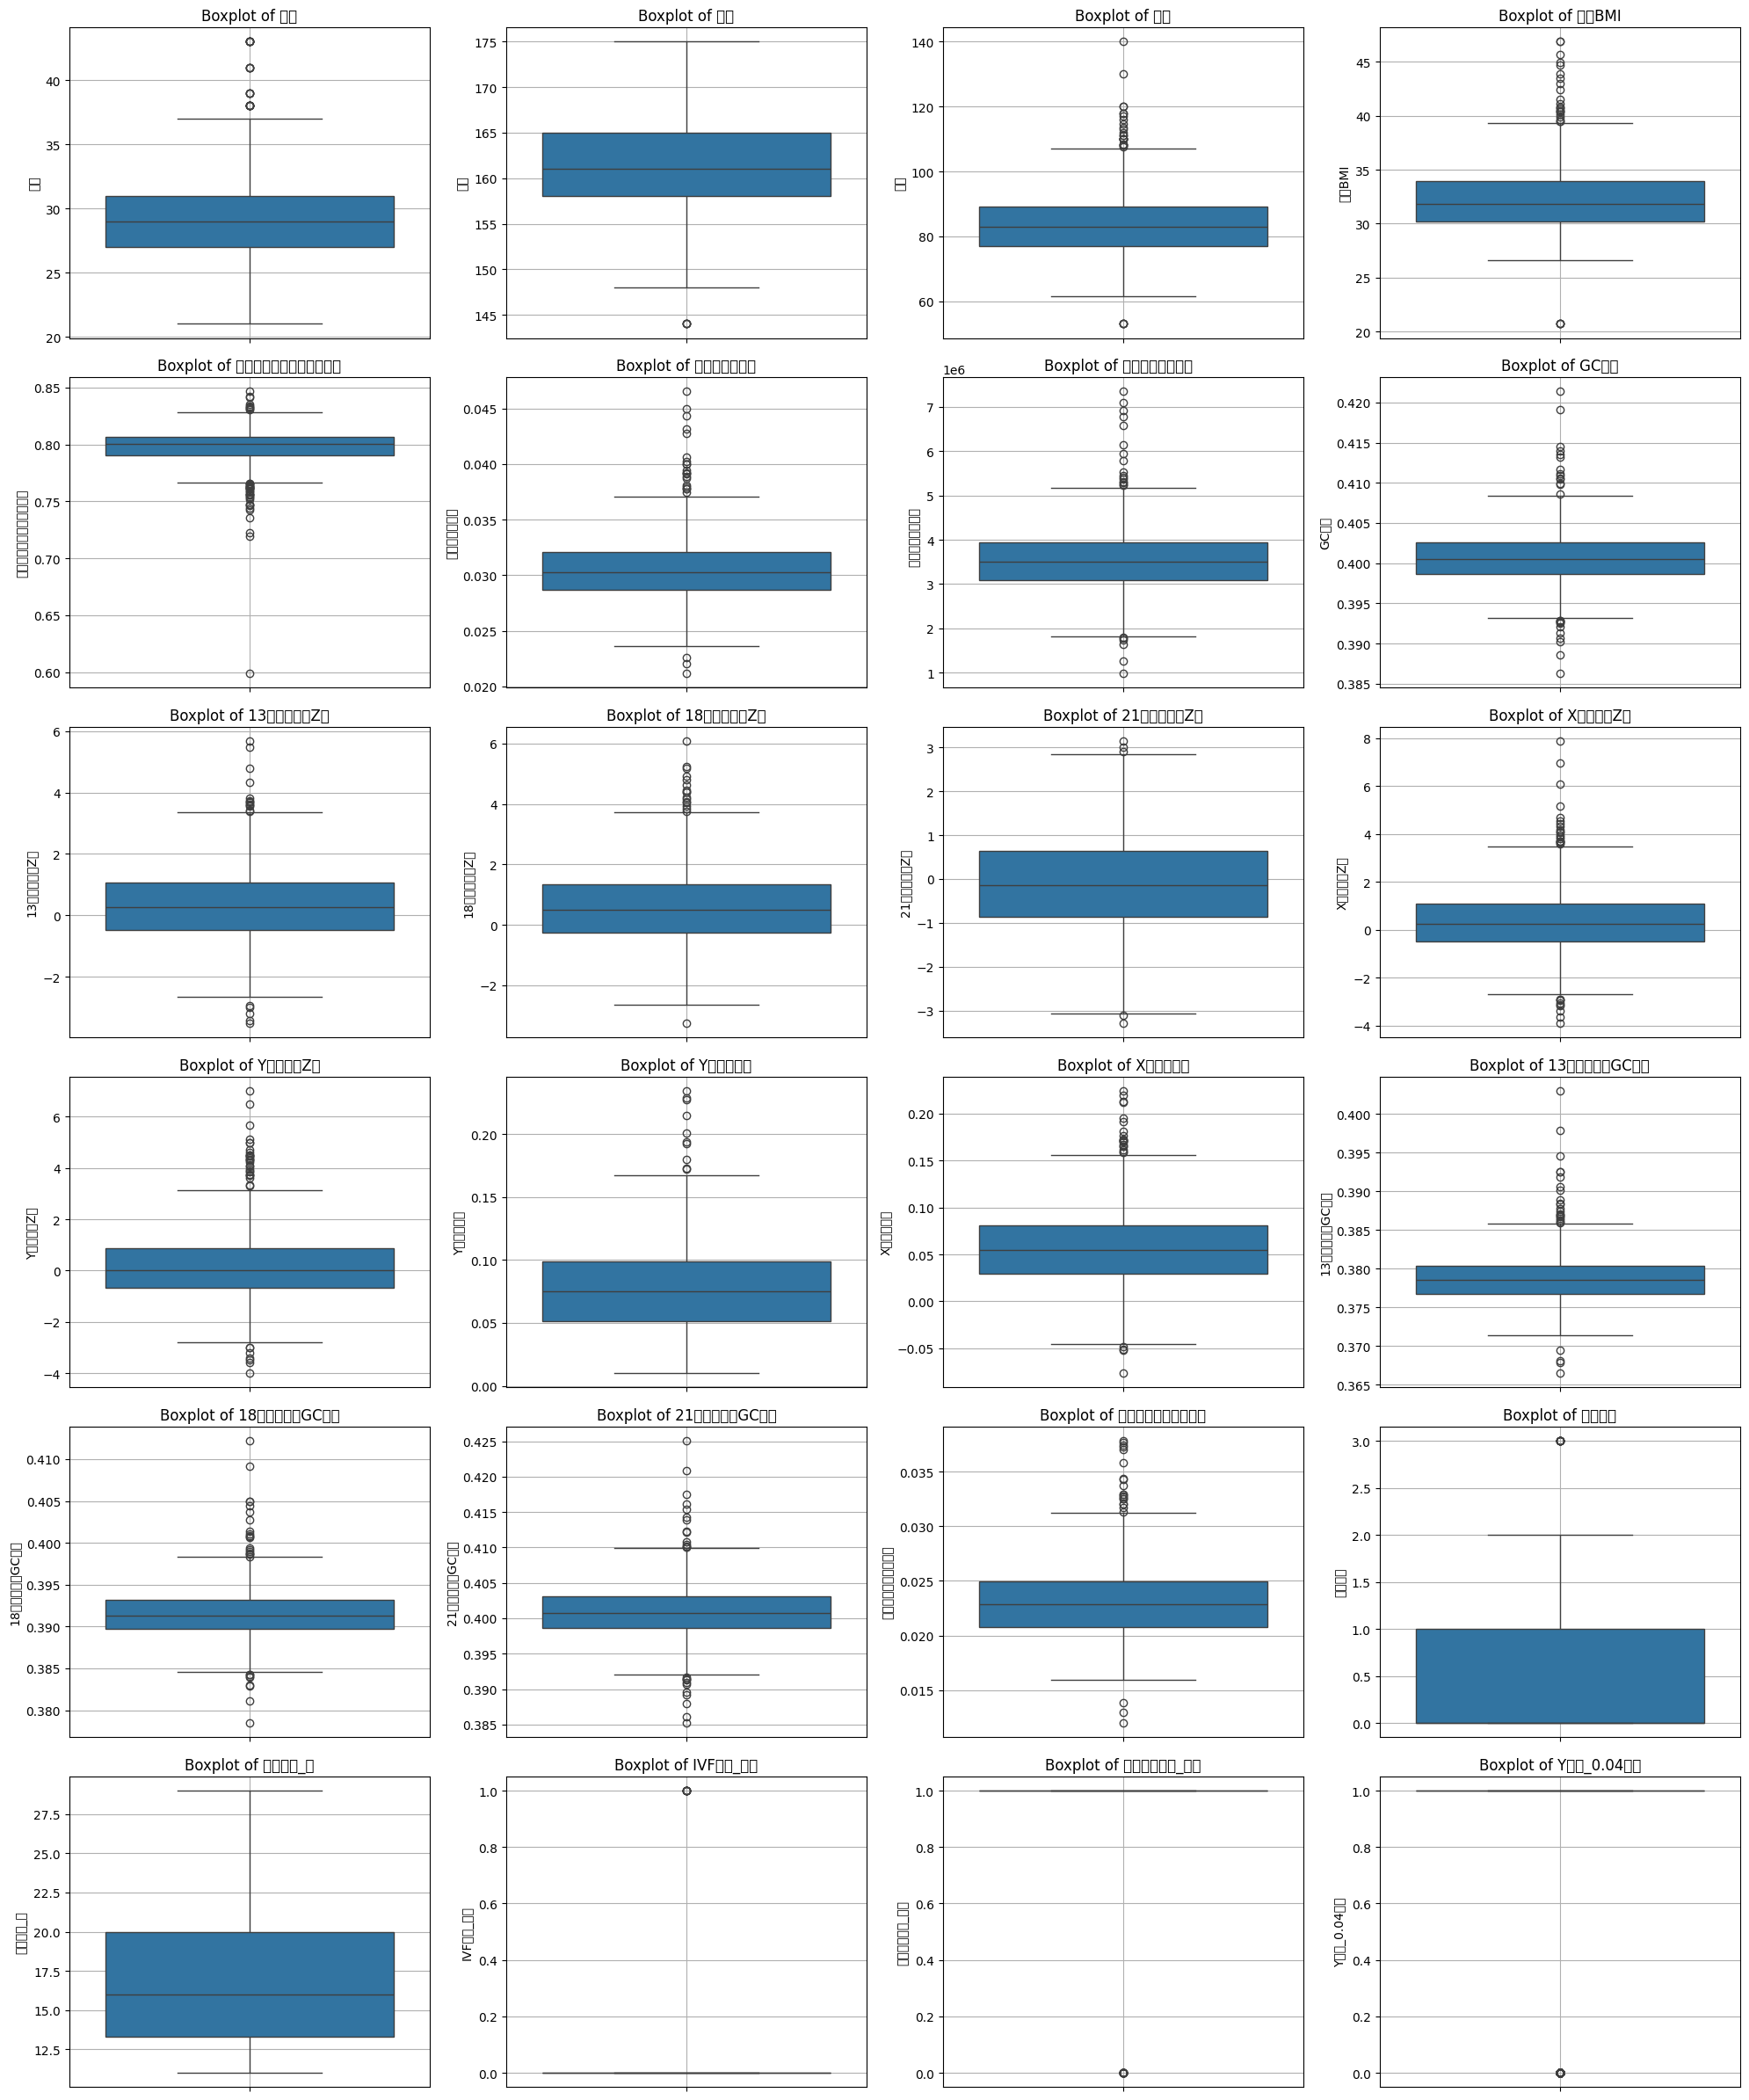

In [14]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
# Number of plots per row
plots_per_row = 4
n = len(numeric_cols)
rows = int(np.ceil(n / plots_per_row))
cols = plots_per_row

# Histograms 直方图：展示数据的分布情况。
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    data[col].hist(ax=axes[idx], bins=50)
    axes[idx].set_title(col)
    axes[idx].grid(False)

# Hide any unused subplots
for idx in range(n, rows * cols):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Boxplots 箱线图：展示数据的集中趋势、离散程度和异常值。
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(y=col, data=data, ax=axes[idx])
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].grid(True)

# Hide any unused subplots
for idx in range(n, rows * cols):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

D:\anaconda\envs\pykan-env\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.draw()
C:\Users\qqq\AppData\Local\Temp\ipykernel_31884\2131245736.py:11: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  plt.savefig("sample_plot.png")
D:\anaconda\envs\pykan-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


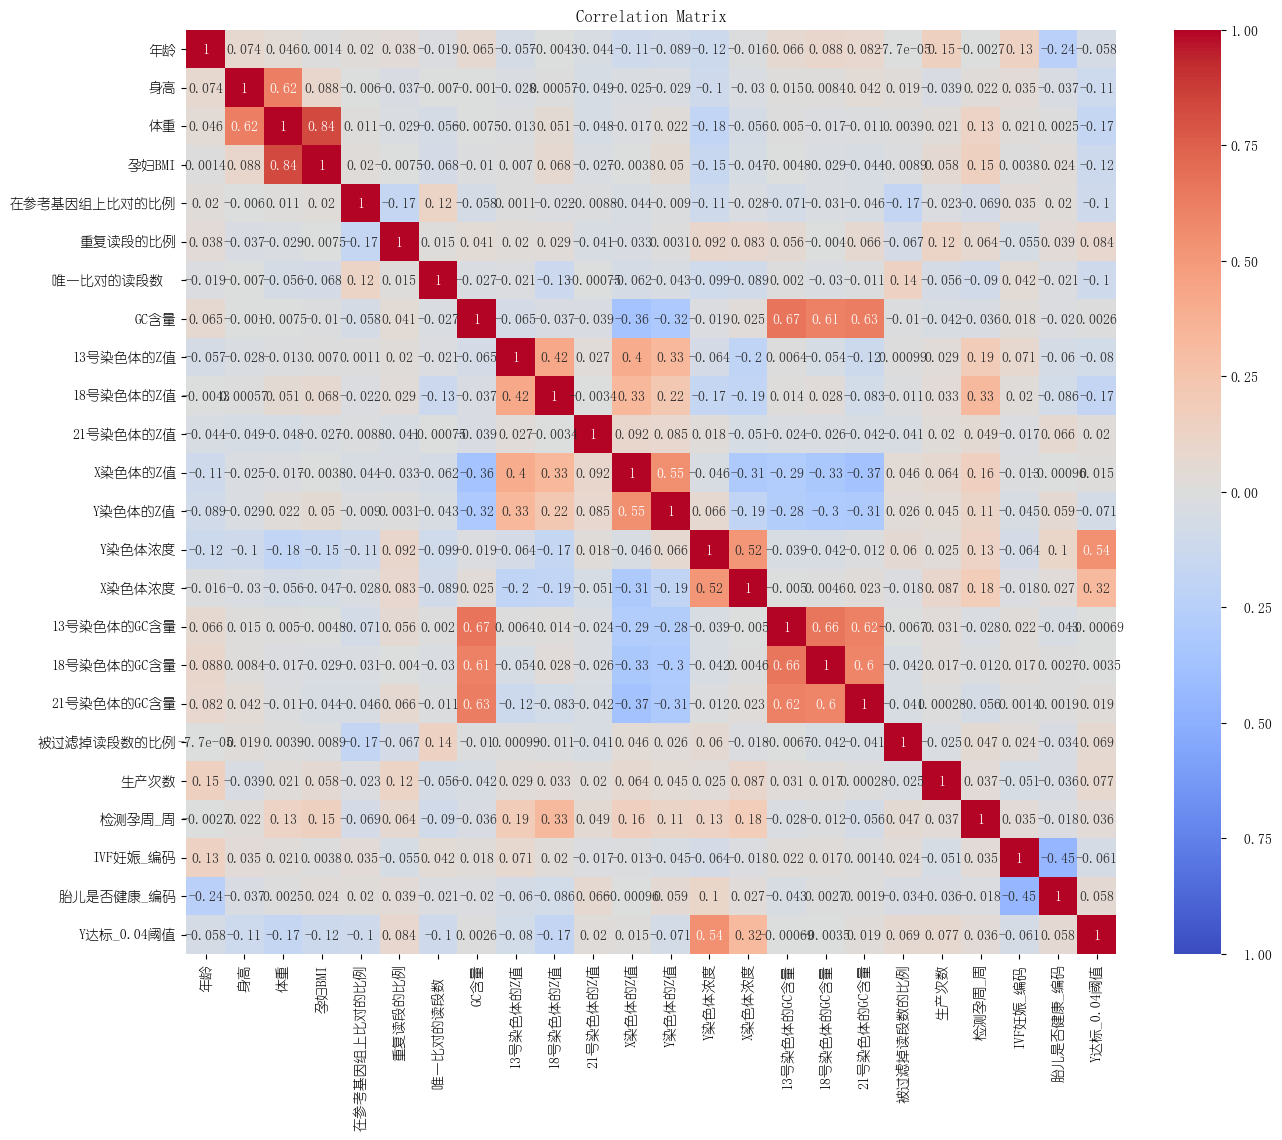

In [20]:
# Select only numeric columns for correlation computation
numeric_cols = data.select_dtypes(include=[np.number])

# Compute the correlation matrix for numeric columns
corr_matrix = numeric_cols.corr()

# Plot the heatmap for the correlation matrix
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.savefig("sample_plot.png")
plt.show()

In [7]:
# 查看转换结果
print(df[['检测孕周_周']].head())

      检测孕周_周
0  11.857143
1  15.857143
2  20.142857
3  22.857143
4  13.857143


In [5]:
# Select features and target variable
# Example: using 'inflation_annual_cpi' and 'exch_usd' as input features
# and 'banking_crisis' as the target (converted to numeric)
'''features = df[['year', 'systemic_crisis', 'domestic_debt_in_default', 'sovereign_external_debt_default', 'gdp_weighted_default', 
               'independence', 'currency_crises', 'inflation_annual_cpi', 'exch_usd']]'''

features = data[['孕妇BMI', '检测孕周_周']]
features = features.fillna(features.mean()).values # replace the null value with the mean
target = data['Y染色体浓度']

'''scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)'''

# Convert to PyTorch tensors
train_input = torch.tensor(features, dtype=torch.float32).to(device)
train_label = torch.tensor(target, dtype=torch.float32).to(device)

# Create dataset dictionary similar to the original example
dataset = {
    'train_input': train_input,
    'train_label': train_label,
    'test_input': train_input.clone(),  # Use the training data as the test data
    'test_label': train_label.clone()
}

# The shapes will show the dimensions of your data
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1082, 2]), torch.Size([1082]))

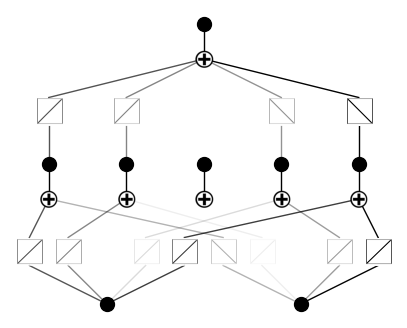

In [6]:
# plot KAN at initialization
model(dataset['train_input']);
model.plot()

| train_loss: 3.65e-02 | test_loss: 3.65e-02 | reg: 2.93e+01 | : 100%|█| 50/50 [00:24<00:00,  2.06it


saving model version 0.1


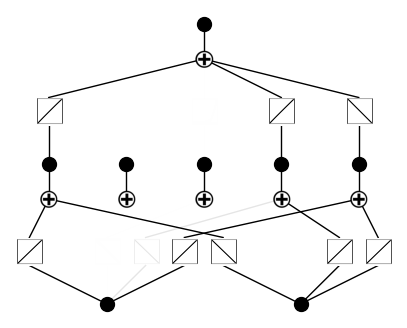

In [7]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.0001,
    update_grid=False)
model.plot()

saving model version 0.2


| train_loss: 6.50e-02 | test_loss: 6.50e-02 | reg: 1.97e+01 | : 100%|█| 50/50 [00:12<00:00,  3.97it

saving model version 0.3


{'train_loss': [array(0.03606396, dtype=float32),
  array(0.03606396, dtype=float32),
  array(0.03592285, dtype=float32),
  array(0.03592285, dtype=float32),
  array(0.03592285, dtype=float32),
  array(0.03592285, dtype=float32),
  array(0.0358012, dtype=float32),
  array(0.03581492, dtype=float32),
  array(0.03747255, dtype=float32),
  array(0.03581165, dtype=float32),
  array(0.05504036, dtype=float32),
  array(0.06498494, dtype=float32),
  array(0.06498495, dtype=float32),
  array(0.06498495, dtype=float32),
  array(0.06498494, dtype=float32),
  array(0.06498495, dtype=float32),
  array(0.06498495, dtype=float32),
  array(0.06498495, dtype=float32),
  array(0.06498495, dtype=float32),
  array(0.06498495, dtype=float32),
  array(0.06498495, dtype=float32),
  array(0.06498495, dtype=float32),
  array(0.06498495, dtype=float32),
  array(0.06498495, dtype=float32),
  array(0.06498494, dtype=float32),
  array(0.06498494, dtype=float32),
  array(0.06498495, dtype=float32),
  array(0.06498

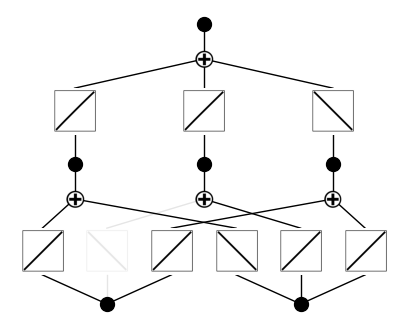

In [8]:
model = model.prune()
model.plot()
# train again after pruning
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.0001,
    update_grid=False)

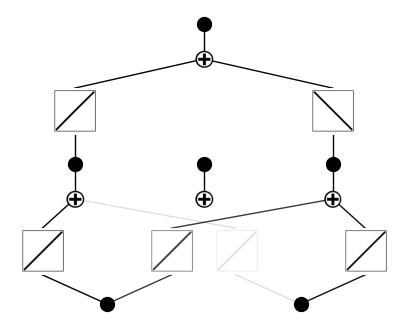

In [9]:
model.plot()

| train_loss: 3.41e-02 | test_loss: 3.41e-02 | reg: 1.45e+01 | : 100%|█| 50/50 [00:17<00:00,  2.90it


saving model version 0.4
saving model version 0.5


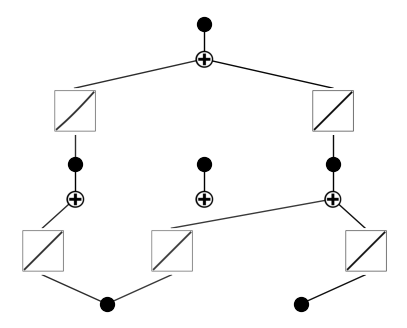

In [10]:
# train again after pruning
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.0001,
    update_grid=False)
model = model.refine(5)
model.plot()

| train_loss: 5.72e-01 | test_loss: 5.72e-01 | reg: 2.25e+01 | : 100%|█| 50/50 [00:07<00:00,  6.44it


saving model version 0.6
saving model version 0.7


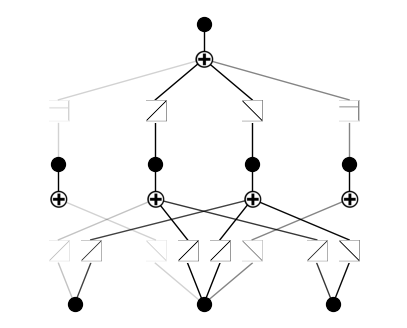

In [8]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model = model.refine(10)
model.plot()

| train_loss: 5.72e-01 | test_loss: 5.72e-01 | reg: 2.24e+01 | : 100%|█| 50/50 [00:12<00:00,  4.00it


saving model version 0.8
saving model version 0.9


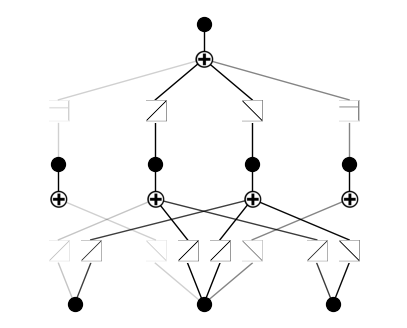

In [9]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model = model.refine(25)
model.plot()

| train_loss: 5.69e-01 | test_loss: 5.69e-01 | reg: 2.01e+01 | : 100%|█| 50/50 [00:19<00:00,  2.56it


saving model version 0.10


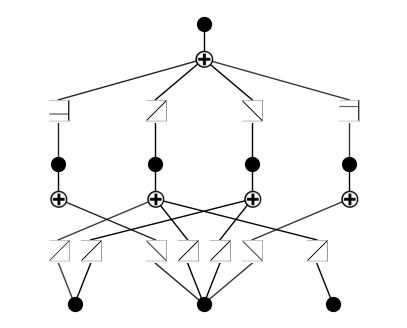

In [10]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model.plot()

| train_loss: 5.69e-01 | test_loss: 5.69e-01 | reg: 2.01e+01 | : 100%|█| 50/50 [00:04<00:00, 10.08it


saving model version 0.11


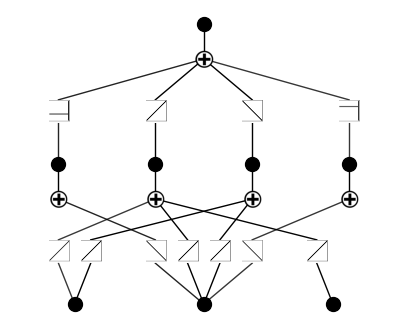

In [11]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model.plot()

In [11]:
lib = SYMBOLIC_LIB  # candidate libraries from SYMBOLIC_LIB
model.auto_symbolic(lib=lib)  # automatically select the best sign function
formula = model.symbolic_formula()[0][0]
nsimplify(formula)

fixing (0,0,0) with x, r2=1.0000004768371582, c=1
fixing (0,0,1) with 0, r2=0.0, c=0
fixing (0,0,2) with x, r2=1.0000003576278687, c=1
fixing (0,1,0) with x, r2=0.9999815225601196, c=1
fixing (0,1,1) with x, r2=1.0000004768371582, c=1
fixing (0,1,2) with x, r2=1.0000004768371582, c=1
fixing (1,0,0) with x^2, r2=0.9999984502792358, c=2
fixing (1,1,0) with 0, r2=0.0, c=0
fixing (1,2,0) with x, r2=1.0000004768371582, c=1
saving model version 0.6


891897202047829*x_1/1000000000000000000 + 53056803238877*x_2/50000000000000000 + 45110919557321*(-74552626845547*x_1/5000000000000000 + 878556576119043*x_2/100000000000000000000 - 1)**2/2000000000000000 - 233716677173667/10000000000000000

In [12]:
ex_round(formula, 4)

0.0009*x_1 + 0.0011*x_2 + 0.0226*(-0.0149*x_1 - 1)**2 - 0.0234